In [ ]:
from convert import tfftrans as tff
import wfdb

In [ ]:
tff_file_path = r"D:\hongsi\SKNA_transform\SKNA_data_transform\07503322.tff"

In [3]:
# 讀取檔案
tff_signal, tff_fields, tff_markers, tff_triggers = tff.rdtff(tff_file_path)

In [4]:
print("Fields:")
for key, value in tff_fields.items():
    print(f"{key}: {value}")    
print("\nMarkers:")
for marker in tff_markers:
    print(marker)
print("\nTriggers:")
for trigger in tff_triggers:
    print(trigger)
print("\nSignal shape:", tff_signal.shape)
print("Fields:", tff_fields)
print("Markers:", tff_markers)
print("Triggers:", tff_triggers)

Fields:
fs: 10000
n_sig: 3
sig_name: ['emg_0', 'emg_1']
base_time: 12:54:42
base_date: 2016-08-30

Markers:
4684818
6313556

Triggers:

Signal shape: (6330908, 3)
Fields: {'fs': 10000, 'n_sig': 3, 'sig_name': ['emg_0', 'emg_1'], 'base_time': datetime.time(12, 54, 42), 'base_date': datetime.date(2016, 8, 30)}
Markers: [4684818 6313556]
Triggers: []


In [5]:
from signals import filtering, resampling

sampling_rate = tff_fields['fs']  

ecg_1_signal = tff_signal[:, 0]
ecg_2_signal = tff_signal[:, 1]
ecg_3_signal = tff_signal[:, 2] 

ecg_1_filtered = filtering.bandpass_filter(ecg_1_signal, lowcut=0.5, highcut=100.0, fs=sampling_rate, order=2)
ecg_2_filtered = filtering.bandpass_filter(ecg_2_signal, lowcut=0.5, highcut=100.0, fs=sampling_rate, order=2)
ecg_3_filtered = filtering.bandpass_filter(ecg_3_signal, lowcut=0.5, highcut=100.0, fs=sampling_rate, order=2)  

ecg_1_resampled = resampling.downsample_signal(ecg_1_filtered, original_fs=sampling_rate, target_fs=1000)
ecg_2_resampled = resampling.downsample_signal(ecg_2_filtered, original_fs=sampling_rate, target_fs=1000)
ecg_3_resampled = resampling.downsample_signal(ecg_3_filtered, original_fs=sampling_rate, target_fs=1000)

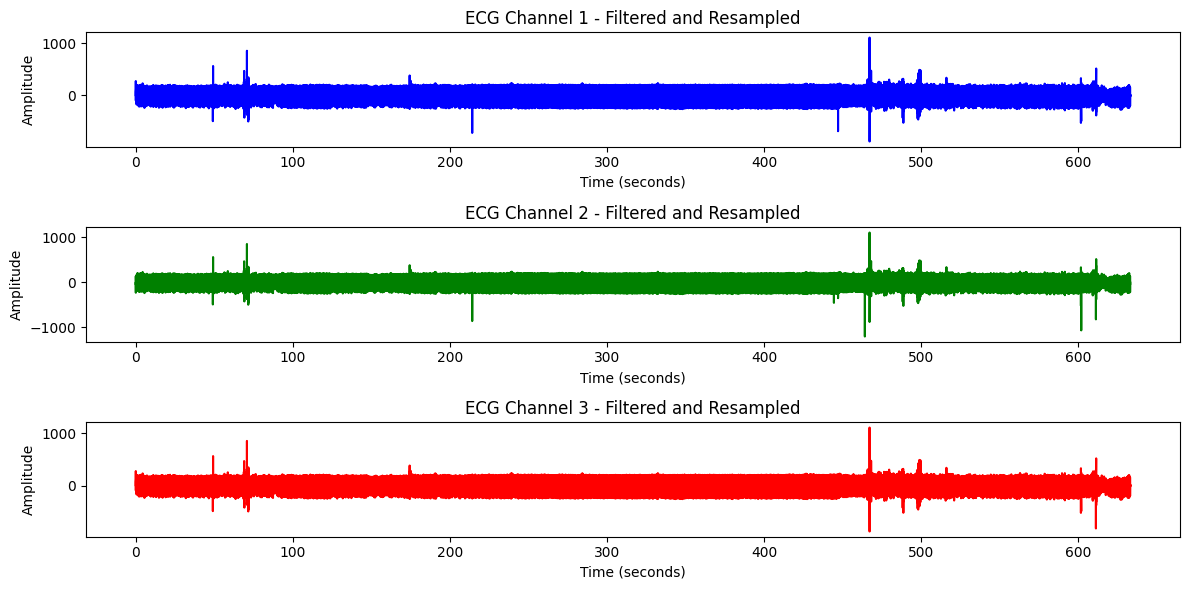

In [6]:
import matplotlib.pyplot as plt
import numpy as np

time_1 = np.arange(len(ecg_1_resampled)) / 1000.0
time_2 = np.arange(len(ecg_2_resampled)) / 1000.
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time_1, ecg_1_resampled, color='blue')
plt.title('ECG Channel 1 - Filtered and Resampled')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.subplot(3, 1, 2)
plt.plot(time_2, ecg_2_resampled, color='green')
plt.title('ECG Channel 2 - Filtered and Resampled')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.subplot(3, 1, 3)
time_3 = np.arange(len(ecg_3_resampled)) / 1000.0
plt.plot(time_3, ecg_3_resampled, color='red')
plt.title('ECG Channel 3 - Filtered and Resampled')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## Find SDNN, LF,HF, LF/HF, DFA alpha1

In [7]:
from analysis import analyzer
import neurokit2 as nk2

HRV Results:    HRV_MeanNN    HRV_SDNN  HRV_SDANN1  HRV_SDNNI1  HRV_SDANN2  HRV_SDNNI2  \
0  637.575605  139.227066   68.012692  110.500339   46.324304  121.304367   

   HRV_SDANN5  HRV_SDNNI5   HRV_RMSSD   HRV_SDSD  ...  HRV_SampEn  HRV_ShanEn  \
0         NaN         NaN  160.489818  160.57081  ...    1.396611    8.322269   

   HRV_FuzzyEn  HRV_MSEn  HRV_CMSEn  HRV_RCMSEn   HRV_CD   HRV_HFD   HRV_KFD  \
0     1.038075  0.658035   1.374573    1.780195  1.10647  1.965942  2.145817   

    HRV_LZC  
0  0.883034  

[1 rows x 91 columns]


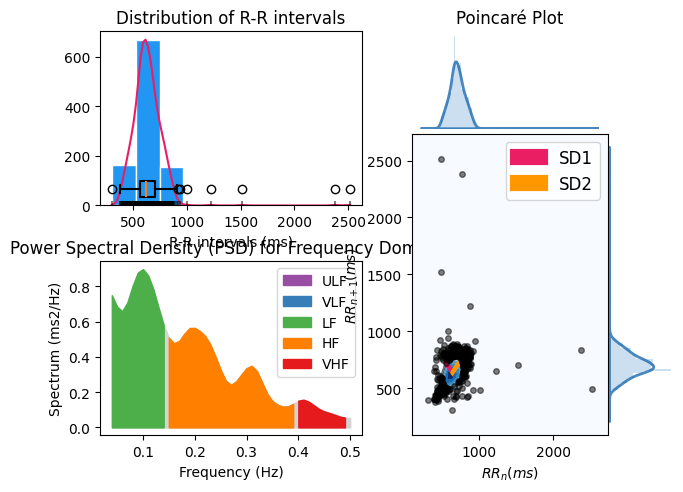

In [8]:
peaks, info = nk2.ecg_peaks(ecg_1_resampled, sampling_rate=1000)
results = nk2.hrv(peaks, sampling_rate=1000, show=True)
print("HRV Results:", results)

In [9]:
hrv_results_1 = analyzer.hrv_analyzer(ecg_1_resampled, sampling_rate=1000)
hrv_results_2 = analyzer.hrv_analyzer(ecg_2_resampled, sampling_rate=1000)


In [10]:
import pandas as pd

print(hrv_results_1)
print(hrv_results_2)
hrv_df = pd.DataFrame([hrv_results_1, hrv_results_2], index=['ECG_1', 'ECG_2'])
hrv_df.to_csv('hrv_results.csv')


{'HRV_SDNN': np.float64(139.23), 'HRV_LF': np.float64(0.03), 'HRV_HF': np.float64(0.04), 'HRV_LF_HF': np.float64(0.9), 'HRV_DFA_alpha1': np.float64(0.65)}
{'HRV_SDNN': np.float64(140.86), 'HRV_LF': np.float64(0.03), 'HRV_HF': np.float64(0.04), 'HRV_LF_HF': np.float64(0.89), 'HRV_DFA_alpha1': np.float64(0.67)}


C:\Users\cccc910715\AppData\Local\Temp\ipykernel_33320\3246816482.py:65: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cccc910715\AppData\Local\Temp\ipykernel_33320\3246816482.py:65: UserWarning: Glyph 24863 (\N{CJK UNIFIED IDEOGRAPH-611F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cccc910715\AppData\Local\Temp\ipykernel_33320\3246816482.py:65: UserWarning: Glyph 21103 (\N{CJK UNIFIED IDEOGRAPH-526F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


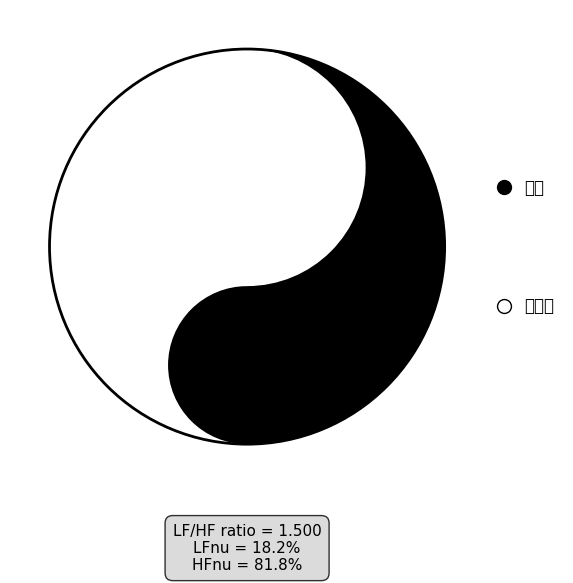

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def create_taichi_plot(lf_hf_ratio, lf_nu=None, hf_nu=None, add_legend=True):
    
    total = 1 + lf_hf_ratio
    sympathetic_ratio = lf_hf_ratio / total    
    parasympathetic_ratio = 1 / total         
    
    sympathetic_ratio = 1/total
    parasympathetic_ratio = lf_hf_ratio/total

    fig, ax = plt.subplots(figsize=(6, 6))
    
    R = 1.0  
    r_sympathetic = R * sympathetic_ratio
    r_parasympathetic = R * parasympathetic_ratio
    
    
    #白底
    base = patches.Circle((0, 0), R, facecolor='white', edgecolor='none')
    ax.add_patch(base)
    
    #右半黑色
    right_half = patches.Wedge((0, 0), R, -90, 90, 
                               facecolor='black', edgecolor='none', linewidth=0)
    ax.add_patch(right_half)
    
    #下方黑色
    bottom_circle = patches.Circle((0, -R + r_sympathetic), r_sympathetic, 
                                  facecolor='black', edgecolor='none', linewidth=0)
    ax.add_patch(bottom_circle)
    
    #上方白色
    top_circle = patches.Circle((0, R - r_parasympathetic), r_parasympathetic, 
                               facecolor='white', edgecolor='none', linewidth=0)
    ax.add_patch(top_circle)
    
    #最外框
    outer_circle = patches.Circle((0, 0), R, fill=False, 
                                 edgecolor='black', linewidth=2)
    ax.add_patch(outer_circle)

    if add_legend:
        legend_x = 1.3
        ax.scatter(legend_x, 0.3, c='black', s=100, marker='o')
        ax.text(legend_x + 0.1, 0.3, '交感', fontsize=12, va='center')
        ax.scatter(legend_x, -0.3, c='white', s=100, marker='o', 
                  edgecolors='black', linewidth=1)
        ax.text(legend_x + 0.1, -0.3, '副交感', fontsize=12, va='center')
    
    if lf_nu is not None and hf_nu is not None:
        info_text = f'LF/HF ratio = {lf_hf_ratio:.3f}\nLFnu = {lf_nu:.1f}%\nHFnu = {hf_nu:.1f}%'
    else:
        info_text = f'LF/HF ratio = {lf_hf_ratio:.3f}\n交感: {sympathetic_ratio*100:.1f}%\n副交感: {parasympathetic_ratio*100:.1f}%'
    
    ax.text(0, -1.4, info_text, ha='center', va='top', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    ax.set_xlim(-1.2, 1.6)
    ax.set_ylim(-1.6, 1.2) 
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    return fig

# 測試代碼 (使用您的數據)
try:
    fig = create_taichi_plot(1.5, 18.2, 81.8)
    plt.show()
except Exception as e:
    print(e)